# <font color=#0099CC>**Investigación LdP — Elección del orden de diferenciación fraccional**</font>

## <font color=#0099CC>**0. INTRODUCCIÓN**</font>

### <font color=#336699>**0.1. Objetivo**</font>

Elegir un valor **global** de `d ∈ [0, 1]` para la diferenciación fraccional (FFD, López de Prado 2018) que aplicará `load_data(d_frac=...)` en los 16 notebooks de investigación.

**Criterio**: el menor `d` que produce series **estacionarias** (test ADF, `p < 0.05`) para la mayoría de los 23 activos del taller, calculado **solo sobre el segmento de train cronológico** (sin peeking de test).

**Salida**: imprime el `d` recomendado para actualizar `D_FRAC_INV` en `01_src_compartido/dataset_utils.py`.

### <font color=#336699>**0.2. Notas que afectan al MAE de los notebooks de investigación**</font>

1. **Unidades del MAE.** `create_dataset` deriva X e Y de la misma serie frac-diff, así que el MAE de los modelos de investigación está en *unidades de frac-diff*, **no** en log-retornos. Es internamente coherente, pero **no directamente comparable** en valor absoluto con el MAE de los notebooks de competición. En el report, comparar como *mejora relativa* frente a un baseline trivial (predicción cero) calculado en la misma escala.

2. **Pérdida de muestras al inicio.** El método FFD descarta las primeras `L-1` filas del histórico (siendo `L` el número de pesos `ω_k` retenidos por el threshold). Para `d=0.4` y `threshold=1e-5`, `L` ronda los varios cientos / pocos miles; con ~16.200 días de histórico la pérdida típica es **1-10 %**.

3. **No peeking.** La elección de `d` se hace **solo sobre el 80 % cronológico inicial** del histórico, dejando el 20 % final como reserva para validación y test en los notebooks de investigación.

Estas notas también están en el encabezado del módulo `01_src_compartido/dataset_utils.py`.

## <font color=#0099CC>**1. ENTORNO E IMPORTACIONES**</font>

### <font color=#336699>**1.1. Detección Colab / local, rutas e imports**</font>

Configura `BASE`, el acceso a Drive cuando aplica y el `sys.path` para importar `dataset_utils` desde `01_src_compartido/`. Importa también las nuevas utilidades de frac-diff y la constante `D_FRAC_INV` (provisional).

In [1]:
import os, sys

def detect_env():
    try:
        import google.colab  # noqa: F401
        return 'colab'
    except ImportError:
        return 'local'

ENV = detect_env()

if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Taller4_DL_MIAX'
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

SRC = os.path.join(BASE, '01_src_compartido')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

from dataset_utils import (
    load_data, TICKERS, N_ASSETS,
    calcular_pesos, aplicar_fracdiff_multi,
    D_FRAC_INV, FRACDIFF_THRESHOLD_DEFAULT,
)

print(f'> Entorno : {ENV}')
print(f'> BASE    : {BASE}')
print(f'> SRC     : {SRC}')
print(f'> D_FRAC_INV (provisional en dataset_utils.py): {D_FRAC_INV}')

> Entorno : local
> BASE    : c:\Users\Javi\Desktop\MIAX\Entregas\Entrega 11 - Redes Neuronales\Taller4_DL_MIAX\Taller4_DL_MIAX
> SRC     : c:\Users\Javi\Desktop\MIAX\Entregas\Entrega 11 - Redes Neuronales\Taller4_DL_MIAX\Taller4_DL_MIAX\01_src_compartido
> D_FRAC_INV (provisional en dataset_utils.py): 0.4


## <font color=#0099CC>**2. DATOS — PRECIOS RAW Y SEGMENTO DE TRAIN CRONOLÓGICO**</font>

### <font color=#336699>**2.1. Descarga y reserva del 20 % final**</font>

Se descargan los cierres ajustados crudos (sin transformar) y se reserva el **80 % cronológico inicial** como segmento de train para el análisis ADF. El 20 % final queda fuera del análisis — será válido para validación y test en los 16 notebooks de investigación. Así se evita peeking de test en la elección del hiperparámetro `d`.

In [2]:
# Cierres ajustados crudos (precios, no log-retornos).
data_raw, df_raw = load_data(use_log_returns=False, verbose=True)

# Trabajamos en log(precio): el caso d=0 es log(precio), d=1 es log-retornos
# y d ∈ (0, 1) es la frac-diff de log(precio).
log_price = np.log(df_raw)

TRAIN_FRAC = 0.80
n_train = int(len(log_price) * TRAIN_FRAC)
log_price_train = log_price.iloc[:n_train]
log_price_oot   = log_price.iloc[n_train:]

print(f'> Histórico total : {log_price.shape[0]:,} días × {log_price.shape[1]} activos')
print(f'> Train (cronológico, 80%): {log_price_train.shape[0]:,} días  '
      f'[{log_price_train.index[0].date()} → {log_price_train.index[-1].date()}]')
print(f'> Reservado (20% final)   : {log_price_oot.shape[0]:,} días  '
      f'[{log_price_oot.index[0].date()} → {log_price_oot.index[-1].date()}]')

> Descargando datos desde 1945-01-01 hasta hoy...


[*********************100%***********************]  23 of 23 completed


> Cierres ajustados — shape (16202, 23)
> Histórico total : 16,202 días × 23 activos
> Train (cronológico, 80%): 12,961 días  [1962-01-02 → 2013-06-27]
> Reservado (20% final)   : 3,241 días  [2013-06-28 → 2026-05-18]


## <font color=#0099CC>**3. BARRIDO DE d × ACTIVO**</font>

### <font color=#336699>**3.1. ADF**</font>

Para cada `d` se aplica `aplicar_fracdiff_multi` a la matriz `(T, 23)` de `log(precio)` de train cronológico (todos los activos en una sola pasada vía convolución por columna), y se calcula el test ADF para cada activo individualmente. Se registra:

- `pmat[d, ticker]` → p-valor ADF
- `L_serie[d]`      → número de pesos `ω_k` retenidos (filas descartadas: `L - 1`)
- `est[d]`          → número de activos estacionarios (`p < 0.05`)

Para velocidad usamos `autolag=None` y `maxlag=12` (≈ 2 semanas de trading): los p-valores ADF son robustos a esta elección y suficientes para elegir un `d` discretizado a múltiplos de 0.1.

In [7]:
THRESHOLD  = FRACDIFF_THRESHOLD_DEFAULT     # 1e-5
ADF_MAXLAG = 12
ADF_ALPHA  = 0.05

ds       = np.round(np.arange(0.0, 1.01, 0.1), 2)
columnas = list(log_price_train.columns)

pmat    = pd.DataFrame(index=ds, columns=columnas, dtype=float)
pmat.index.name = 'd'
L_serie = pd.Series(index=ds, dtype=int, name='L')

X_train = log_price_train.values.astype(np.float64)

for d in ds:
    if d == 0.0:
        # Caso degenerado de frac-diff: pesos=[1.0], L=1 → log(precio) tal cual.
        fd, L = X_train, 1
    else:
        fd, L = aplicar_fracdiff_multi(X_train, d=float(d), threshold=THRESHOLD)
    L_serie.loc[d] = L

    for j, ticker in enumerate(columnas):
        stat, pval, *_ = adfuller(fd[:, j], maxlag=ADF_MAXLAG, autolag=None)
        pmat.loc[d, ticker] = pval

est = (pmat < ADF_ALPHA).sum(axis=1).rename('n_estacionarios')

resumen = pd.concat([L_serie, est], axis=1)
resumen['frac_estacionarios'] = resumen['n_estacionarios'] / N_ASSETS
resumen['filas_descartadas']  = resumen['L'] - 1

print('Resumen del barrido (sobre train cronológico):')
print(resumen.to_string(float_format=lambda x: f'{x:.3f}'))

Resumen del barrido (sobre train cronológico):
           L  n_estacionarios  frac_estacionarios  filas_descartadas
0.0    1.000                0               0.000              0.000
0.1 4076.000                0               0.000           4075.000
0.2 3382.000                3               0.130           3381.000
0.3 2275.000               14               0.609           2274.000
0.4 1458.000               23               1.000           1457.000
0.5  927.000               23               1.000            926.000
0.6  590.000               23               1.000            589.000
0.7  372.000               23               1.000            371.000
0.8  228.000               23               1.000            227.000
0.9  125.000               23               1.000            124.000
1.0    2.000               23               1.000              1.000


## <font color=#0099CC>**4. VISUALIZACIÓN**</font>

### <font color=#336699>**4.1. Tres paneles**</font>

- **Panel A**: heatmap del p-valor ADF (`d × activo`). Verde = estacionaria (`p < 0.05`).
- **Panel B**: nº de activos estacionarios vs `d` (con umbral 90 %).
- **Panel C**: pérdida de muestras (`L - 1`) vs `d` — coste de elegir un `d` pequeño.

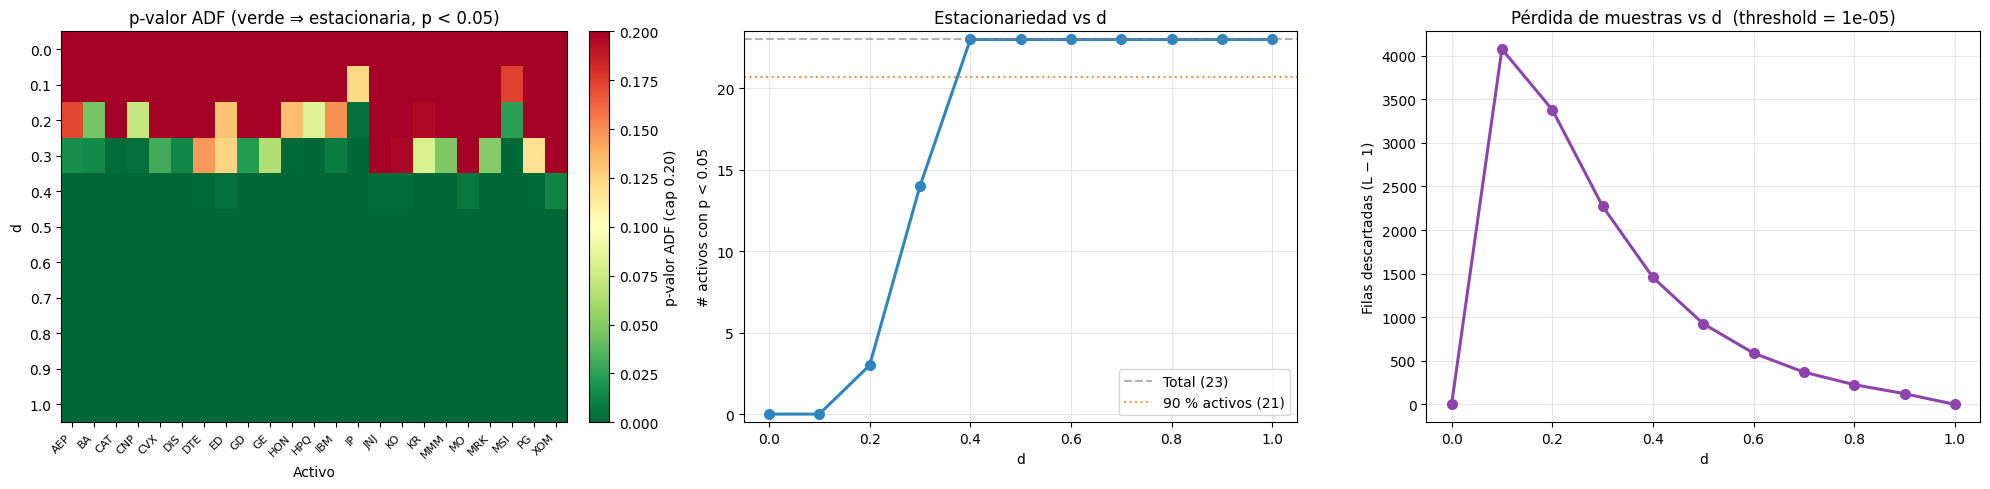

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel A — heatmap p-valor ADF
ax = axes[0]
im = ax.imshow(pmat.values.astype(float), aspect='auto', cmap='RdYlGn_r',
               vmin=0.0, vmax=0.20)
ax.set_yticks(range(len(ds)))
ax.set_yticklabels([f'{d:.1f}' for d in ds])
ax.set_xticks(range(len(columnas)))
ax.set_xticklabels(columnas, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Activo')
ax.set_ylabel('d')
ax.set_title('p-valor ADF (verde ⇒ estacionaria, p < 0.05)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='p-valor ADF (cap 0.20)')

# Panel B — # activos estacionarios vs d
ax = axes[1]
ax.plot(ds, est.values, 'o-', lw=2.2, ms=7, color='#2E86C1')
ax.axhline(N_ASSETS, color='gray', ls='--', alpha=0.6, label=f'Total ({N_ASSETS})')
ax.axhline(N_ASSETS * 0.9, color='#E67E22', ls=':', alpha=0.8,
           label=f'90 % activos ({int(np.ceil(N_ASSETS*0.9))})')
ax.set_xlabel('d')
ax.set_ylabel('# activos con p < 0.05')
ax.set_title('Estacionariedad vs d')
ax.set_ylim(-0.5, N_ASSETS + 0.5)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

# Panel C — pérdida de muestras (L-1) vs d
ax = axes[2]
filas_dropped = (L_serie.values - 1).astype(int)
ax.plot(ds, filas_dropped, 'o-', lw=2.2, ms=7, color='#8E44AD')
ax.set_xlabel('d')
ax.set_ylabel('Filas descartadas (L − 1)')
ax.set_title(f'Pérdida de muestras vs d  (threshold = {THRESHOLD:.0e})')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## <font color=#0099CC>**5. DECISIÓN — `d` global recomendado**</font>

### <font color=#336699>**5.1. Criterio**</font>

Menor `d` tal que al menos el **90 %** de los 23 activos sean estacionarios (`p < 0.05`).

- Si ningún `d` en `[0, 1]` alcanza el 90 %, relaja a 50 %.
- Si varios `d` empatan, elige el **menor** (más memoria preservada).

Resultado: se imprime el `d` recomendado y las instrucciones para actualizar la constante `D_FRAC_INV` en `01_src_compartido/dataset_utils.py`.

In [14]:
UMBRAL_ESTRICTO = 0.90
UMBRAL_RELAJADO = 0.50

n_estricto = int(np.ceil(UMBRAL_ESTRICTO * N_ASSETS))
n_relajado = int(np.ceil(UMBRAL_RELAJADO * N_ASSETS))

cand_estricto = est[est >= n_estricto].index.tolist()
if cand_estricto:
    d_recomendado = float(min(cand_estricto))
    motivo = f'menor d con ≥ {int(UMBRAL_ESTRICTO*100)}% activos estacionarios (≥ {n_estricto}/{N_ASSETS})'
else:
    cand_relax = est[est >= n_relajado].index.tolist()
    if cand_relax:
        d_recomendado = float(min(cand_relax))
        motivo = (f'NINGÚN d alcanza {int(UMBRAL_ESTRICTO*100)}%; '
                  f'se relaja a ≥ {int(UMBRAL_RELAJADO*100)}% (≥ {n_relajado}/{N_ASSETS})')
    else:
        d_recomendado = 1.0
        motivo = 'NINGÚN d alcanza ni el 50%; se usa d=1.0 (log-retornos)'

L_rec      = int(L_serie.loc[d_recomendado])
n_dropped  = L_rec - 1
pct_dropped = 100.0 * n_dropped / len(log_price)
n_est_rec  = int(est.loc[d_recomendado])

print('=' * 75)
print(f'> "d" recomendado:        {d_recomendado:.2f}')
print(f'> Motivo:                 {motivo}')
print(f'> Activos estacionarios:  {n_est_rec:>2}/{N_ASSETS}')
print(f'> L (pesos retenidos):    {L_rec}')
print(f'> Filas descartadas:      {n_dropped}  ({pct_dropped:.2f}% del histórico)')
print('=' * 75)

> "d" recomendado:        0.40
> Motivo:                 menor d con ≥ 90% activos estacionarios (≥ 21/23)
> Activos estacionarios:  23/23
> L (pesos retenidos):    1458
> Filas descartadas:      1457  (8.99% del histórico)


## <font color=#0099CC>**6. RECORDATORIO — Consecuencias del "d" elegido sobre los modelos**</font>

Una vez fijado `D_FRAC_INV`, los 16 notebooks de investigación trabajarán sobre series frac-diff. Recuérdese:

- **MAE en unidades de frac-diff**, no de log-retornos. En las tablas y gráficas de comparación entre competición e investigación, comparar como *mejora relativa* contra un baseline trivial (predicción cero) calculado en la misma escala. El valor absoluto del MAE no se compara directamente entre tracks.

- **Pérdida de muestras al inicio del histórico**: las primeras `L − 1` filas desaparecen al cargar (ver Sección 2 y panel C de la Sección 4). En la práctica, el primer dato disponible empieza algunos años después de 1962, dependiendo del `d` final.

- **No peeking**: la elección de `d` se ha hecho sobre el 80 % cronológico inicial; el 20 % final queda libre para val/test.

Estas mismas notas están duplicadas en el encabezado de `01_src_compartido/dataset_utils.py` para que también sean visibles desde cualquier notebook que importe el módulo.